<a href="https://colab.research.google.com/github/cavinraj/Data-Science-Assignment/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
path = "/content/cleaned_loan_dataset.csv"

In [ ]:
# Load the dataset
df = pd.read_csv(path)

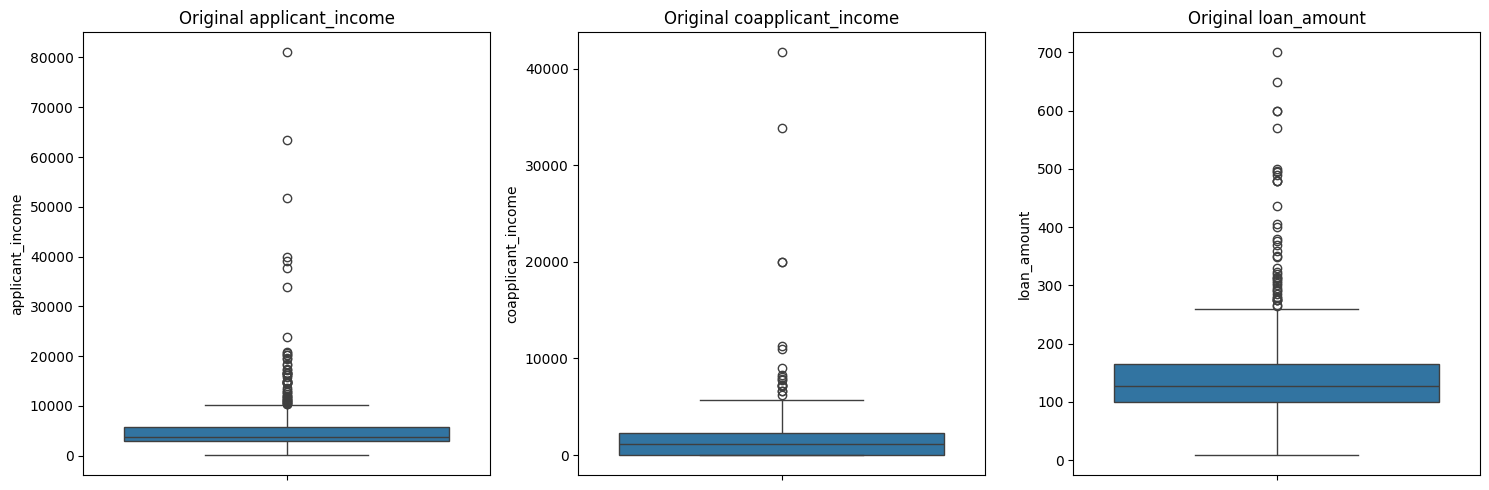

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#VISUALIZING OUTLIERS BEFORE HANDLING
#scan for the outliers in the key numerical columns before engineering features
numerical_cols = ['applicant_income', 'coapplicant_income', 'loan_amount']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Original {col}')
plt.tight_layout()
plt.show()

In [ ]:
#define the capping function (Winsorization using IQR)
def handle_outliers(dataframe, columns):
    df_capped = dataframe.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        #define Upper and Lower bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        #cap the outliers
        #replace values > upper_bound with upper_bound
        #replace values < lower_bound with lower_bound (though rare for income)
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound,
                                np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col]))

        print(f"Capped {col}: Upper Limit = {upper_bound:.2f}")
    return df_capped


Capped applicant_income: Upper Limit = 10171.25
Capped coapplicant_income: Upper Limit = 5743.12
Capped loan_amount: Upper Limit = 261.50


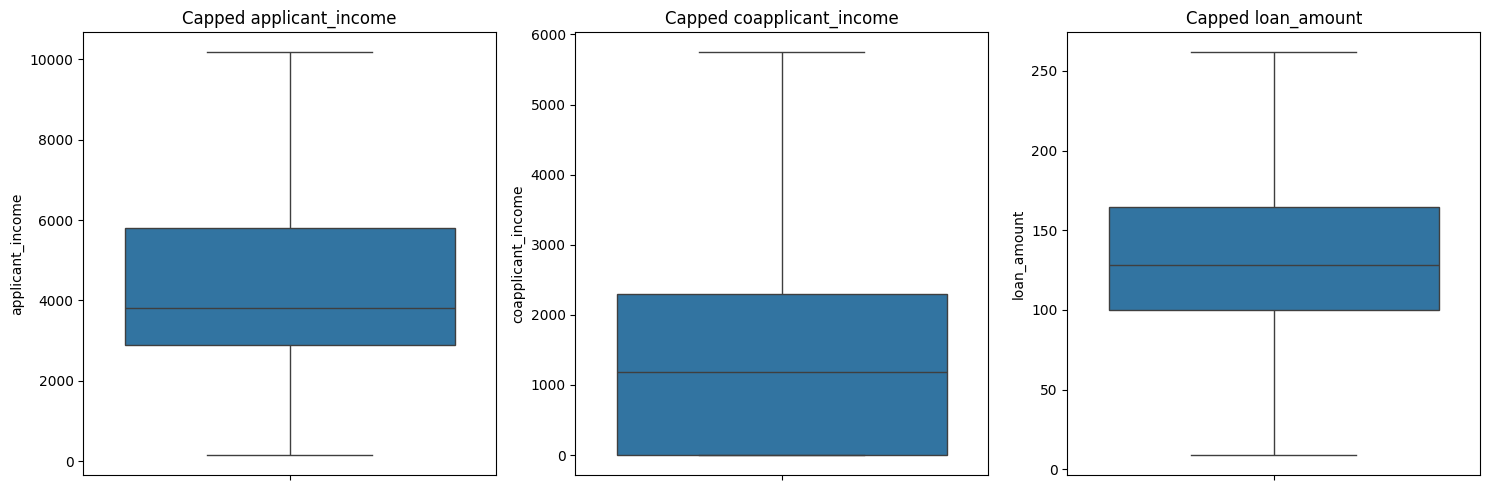

In [ ]:
#apply the function to your numerical columns
numerical_cols = ['applicant_income', 'coapplicant_income', 'loan_amount']
df = handle_outliers(df, numerical_cols)

#visualize the results to confirm outliers are handled
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Capped {col}')
plt.tight_layout()
plt.show()

In [ ]:
#add total_income column
df['total_income'] = df['applicant_income'] + df['coapplicant_income']

#add log columns to normalize the data
df['total_income_log'] = np.log(df['total_income'])
df['loan_amount_log'] = np.log(df['loan_amount'])

In [ ]:
df = df.drop(['loan_amount'], axis=1)

In [ ]:
df.head()

,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount_term,credit_history,property_area,loan_status,total_income_log,total_income,loan_amount_log
0,0,Graduate,No,5849.0,0.0,360.0,1.0,Urban,Y,8.674026,5849.0,4.852030
1,1,Graduate,No,4583.0,1508.0,360.0,1.0,Rural,N,8.714568,6091.0,4.852030
2,0,Graduate,Yes,3000.0,0.0,360.0,1.0,Urban,Y,8.006368,3000.0,4.189655
3,0,Not Graduate,No,2583.0,2358.0,360.0,1.0,Urban,Y,8.505323,4941.0,4.787492
4,0,Graduate,No,6000.0,0.0,360.0,1.0,Urban,Y,8.699515,6000.0,4.948760


<Axes: >

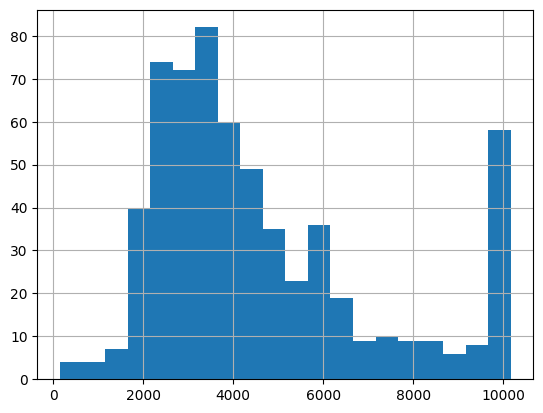

In [ ]:
#visualize the distribution of applicant_income
df['applicant_income'].hist(bins=20)

In [ ]:
# Combine applicant and coapplicant income into one feature
df['total_income'] = df['applicant_income'] + df['coapplicant_income']

<Axes: >

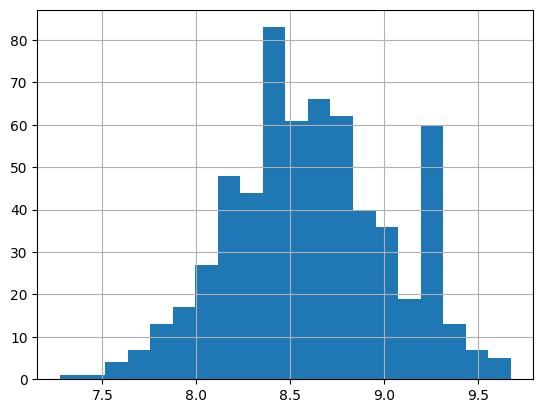

In [ ]:
# Apply log transformation to normalize the distribution
df['total_income_log'] = np.log(df['total_income'])

#visualize the distribution of income_log
df['total_income_log'].hist(bins=20)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

#list of categorical columns to encode
cols = ['education', 'self_employed', 'property_area', 'loan_status']

for col in cols:
    df[col] = le.fit_transform(df[col])

df.head()

,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount_term,credit_history,property_area,loan_status,total_income_log,total_income,loan_amount_log
0,0,0,0,5849.0,0.0,360.0,1.0,2,1,8.674026,5849.0,4.852030
1,1,0,0,4583.0,1508.0,360.0,1.0,0,0,8.714568,6091.0,4.852030
2,0,0,1,3000.0,0.0,360.0,1.0,2,1,8.006368,3000.0,4.189655
3,0,1,0,2583.0,2358.0,360.0,1.0,2,1,8.505323,4941.0,4.787492
4,0,0,0,6000.0,0.0,360.0,1.0,2,1,8.699515,6000.0,4.948760


In [ ]:
columns_to_drop = ['applicant_income', 'coapplicant_income', 'total_income']
#drop them using axis=1 (which means "columns")
df = df.drop(columns_to_drop, axis=1)

In [ ]:
df.to_csv("post_feature_engineering_2.csv")